In [1]:
from data_manage import Data_Manager

data_toolbox = Data_Manager(centralised=True)

In [2]:
data_toolbox.train_data.info

{'python_class': 'ChestMNIST',
 'description': 'The ChestMNIST is based on the NIH-ChestXray14 dataset, a dataset comprising 112,120 frontal-view X-Ray images of 30,805 unique patients with the text-mined 14 disease labels, which could be formulized as a multi-label binary-class classification task. We use the official data split, and resize the source images of 1×1024×1024 into 1×28×28.',
 'url': 'https://zenodo.org/records/10519652/files/chestmnist.npz?download=1',
 'MD5': '02c8a6516a18b556561a56cbdd36c4a8',
 'url_64': 'https://zenodo.org/records/10519652/files/chestmnist_64.npz?download=1',
 'MD5_64': '9de6cd0b934ebb5b7426cfba5efbae16',
 'url_128': 'https://zenodo.org/records/10519652/files/chestmnist_128.npz?download=1',
 'MD5_128': 'db107e5590b27930b62dbaf558aebee3',
 'url_224': 'https://zenodo.org/records/10519652/files/chestmnist_224.npz?download=1',
 'MD5_224': '45bd33e6f06c3e8cdb481c74a89152aa',
 'task': 'multi-label, binary-class',
 'label': {'0': 'atelectasis',
  '1': 'cardi

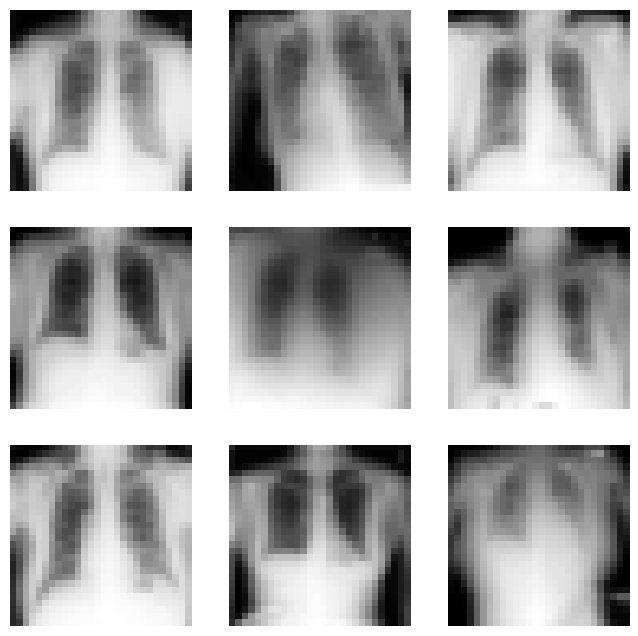

In [3]:
import matplotlib.pyplot as plt
import torch

labels_map = {
    0: 'atelectasis',
    1: 'cardiomegaly',
    2: 'effusion',
    3: 'infiltration',
    4: 'mass',
    5: 'nodule',
    6: 'pneumonia',
    7: 'pneumothorax',
    8: 'consolidation',
    9: 'edema',
    10: 'emphysema',
    11: 'fibrosis',
    12: 'pleural',
    13: 'hernia',
}

figure = plt.figure(figsize=(8, 8))
cols, rows = 3, 3
for i in range(1, cols * rows + 1):
    sample_idx = torch.randint(len(data_toolbox.train_data), size=(1,)).item()
    img, label = data_toolbox.train_data[sample_idx]
    figure.add_subplot(rows, cols, i)
    plt.axis("off")
    plt.imshow(img.permute(1,2,0), cmap="gray")
plt.show()

In [4]:
dataloaders = data_toolbox.get_dataloaders()

In [5]:
from model import ResNet18
from model_manage import Model_Manager

classes = len(data_toolbox.train_data.info["label"])
channels = data_toolbox.train_data.info["n_channels"]

device = "cuda" if torch.cuda.is_available() else "cpu"
model = ResNet18(channels,classes).to(device)
model_toolbox = Model_Manager(model,centralised=True)

In [6]:
print(model_toolbox.model)

ResNet18(
  (conv1): Conv2d(1, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3))
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU()
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layers64): Sequential(
    (0): ResidualBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU()
    )
    (1): ResidualBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (bn2): Bat

In [7]:
from model_functions import train_val_loop
epochs = 100
model_toolbox.logs = train_val_loop(model,model_toolbox.get_config(),dataloaders,epochs,model_toolbox.logs,model_toolbox)

---| Epoch : 1 |---
Loss: 0.720899  [  320/78468]
Loss: 0.648553  [ 8320/78468]
Loss: 0.580013  [16320/78468]
Loss: 0.513410  [24320/78468]
Loss: 0.448714  [32320/78468]
Loss: 0.397920  [40320/78468]
Loss: 0.367304  [48320/78468]
Loss: 0.340251  [56320/78468]
Loss: 0.304426  [64320/78468]
Loss: 0.283408  [72320/78468]
Train Error: Accuracy: 84.4%, Average Loss: 0.440808
Test Error: Accuracy: 94.9%, Average Loss: 0.279678
[save_best_local_model] saving best local model
---| Epoch : 2 |---
Loss: 0.283620  [  320/78468]
Loss: 0.258072  [ 8320/78468]
Loss: 0.256288  [16320/78468]
Loss: 0.249475  [24320/78468]
Loss: 0.240898  [32320/78468]
Loss: 0.242647  [40320/78468]
Loss: 0.230133  [48320/78468]
Loss: 0.220152  [56320/78468]
Loss: 0.233196  [64320/78468]
Loss: 0.222138  [72320/78468]
Train Error: Accuracy: 94.9%, Average Loss: 0.241679
Test Error: Accuracy: 94.9%, Average Loss: 0.219028
[save_best_local_model] saving best local model
---| Epoch : 3 |---
Loss: 0.213311  [  320/78468]
Loss

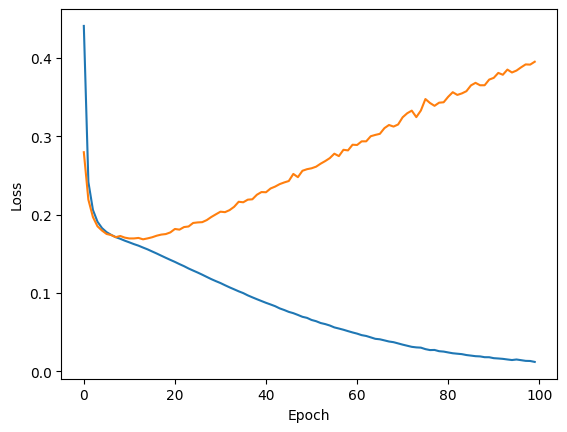

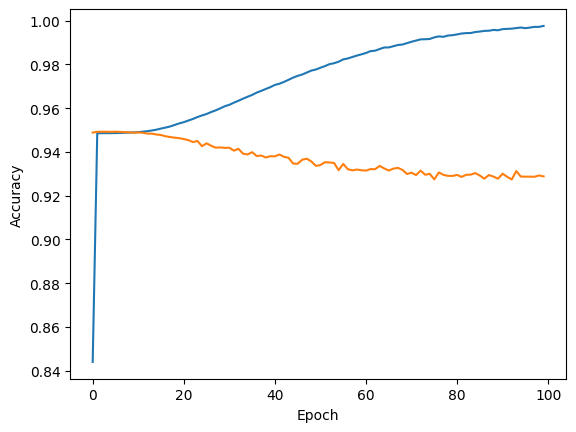

In [8]:
import matplotlib.pyplot as plt

plt.plot(model_toolbox.logs[0][0])
plt.plot(model_toolbox.logs[1][0])
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

plt.plot(model_toolbox.logs[0][1])
plt.plot(model_toolbox.logs[1][1])
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.show()

In [9]:
model_toolbox.save_logs()

True